In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./data/data.csv")
orig_sz = len(df)

In [3]:
df.rename(columns={
    "Unnamed: 0": "index"
}, inplace=True)
df.set_index("index", inplace=True)
df.dropna(inplace=True)
df.head()

,brand,model,color,registration_date,year,price_in_euro,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,offer_description
index,,,,,,,,,,,,,,
0,alfa-romeo,Alfa Romeo GTV,red,10/1995,1995,1300,148,201,Manual,Petrol,"10,9 l/100 km",260 g/km,160500.0,2.0 V6 TB
3,alfa-romeo,Alfa Romeo Spider,black,07/1995,1995,4900,110,150,Manual,Petrol,"9,5 l/100 km",225 g/km,189500.0,2.0 16V Twin Spark L
4,alfa-romeo,Alfa Romeo 164,red,11/1996,1996,17950,132,179,Manual,Petrol,"7,2 l/100 km",- (g/km),96127.0,"3.0i Super V6, absoluter Topzustand !"
5,alfa-romeo,Alfa Romeo Spider,red,04/1996,1996,7900,110,150,Manual,Petrol,"9,5 l/100 km",225 g/km,47307.0,2.0 16V Twin Spark
6,alfa-romeo,Alfa Romeo 145,red,12/1996,1996,3500,110,150,Manual,Petrol,"8,8 l/100 km",210 g/km,230000.0,Quadrifoglio


In [4]:
print(df["fuel_type"].unique())

<StringArray>
[       'Petrol',        'Diesel',        'Hybrid',           'LPG',
         'Other',       '07/2004',       '06/2014',           'CNG',
 'Diesel Hybrid',       '12/2016',       '12/2019',      'Electric',
       'Ethanol',    '264.000 km',       '05/2009',    '180.000 km',
       '04/2013',       '03/2014',       '08/2014',       '01/2016',
       '03/2017',        'Manual',       '04/2008',       '07/2007',
       '12/2012',       '10/2022',       '06/2004',       '09/2009',
       '12/2014',       '02/2017',       '08/2018',       '03/2019',
       '11/2021',      'Hydrogen',       '05/2015',       '03/2018',
       '04/2022',       '04/2000',       '06/2009',       '05/2012',
       '10/2015',     'Automatic',       '03/2021',         '26890',
         '26990',       '11/2005',       '07/2005',       '08/2011',
       '02/2011',       '03/2011',       '10/2013',       '09/2015',
       '02/2018',       '02/2023',       '08/2017',     '99.900 km',
     '13.610 km',   

In [5]:
fault_month_year_indices = df.query("fuel_type.str.contains('\d{2}/\d{4}')").index
df.drop(fault_month_year_indices, inplace=True)
fault_mileage_indices = df.query("fuel_type.str.contains('\d+\.\d{3}')").index
df.drop(fault_mileage_indices, inplace=True)
fault_transmission_indices = df[(df["fuel_type"] == "Automatic") | (df["fuel_type"] == "Manual")].index
df.drop(fault_transmission_indices, inplace=True)
fault_digits = df.query("fuel_type.str.contains('\d+')").index
df.drop(fault_digits, inplace=True)

In [6]:
print(df["fuel_type"].unique())

<StringArray>
[       'Petrol',        'Diesel',        'Hybrid',           'LPG',
         'Other',           'CNG', 'Diesel Hybrid',      'Electric',
       'Ethanol',      'Hydrogen',       'Unknown']
Length: 11, dtype: str


In [7]:
cleaned_sz = len(df)

In [8]:
print(f"Original #Rows: {orig_sz:,}")
print(f"Cleaned #Rows: {cleaned_sz:,}")
print("Fault%:", 100*(1-cleaned_sz/orig_sz))

Original #Rows: 251,079
Cleaned #Rows: 223,733
Fault%: 10.891392748895768


In [9]:
df["power_kw"] = df["power_kw"].astype("int")
df["power_kw"] = df["power_kw"].astype("int")
df["power_ps"] = df["power_ps"].astype("int")
df["price_in_euro"] = df["price_in_euro"].astype("int")
df["registration_date"] = pd.to_datetime(
    df["registration_date"].map(lambda s: s.strip()),
    format="%m/%Y"
)
df["fuel_consumption_l_100km"] = (
    df["fuel_consumption_l_100km"]
        .str.replace(",", ".", regex=False)
        .str.extract(r"([\d.]+)", expand=False)
        .astype(float)
)


In [10]:
df.head()

,brand,model,color,registration_date,year,price_in_euro,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,offer_description
index,,,,,,,,,,,,,,
0,alfa-romeo,Alfa Romeo GTV,red,1995-10-01,1995,1300,148,201,Manual,Petrol,10.9,260 g/km,160500.0,2.0 V6 TB
3,alfa-romeo,Alfa Romeo Spider,black,1995-07-01,1995,4900,110,150,Manual,Petrol,9.5,225 g/km,189500.0,2.0 16V Twin Spark L
4,alfa-romeo,Alfa Romeo 164,red,1996-11-01,1996,17950,132,179,Manual,Petrol,7.2,- (g/km),96127.0,"3.0i Super V6, absoluter Topzustand !"
5,alfa-romeo,Alfa Romeo Spider,red,1996-04-01,1996,7900,110,150,Manual,Petrol,9.5,225 g/km,47307.0,2.0 16V Twin Spark
6,alfa-romeo,Alfa Romeo 145,red,1996-12-01,1996,3500,110,150,Manual,Petrol,8.8,210 g/km,230000.0,Quadrifoglio


In [11]:
df[df["fuel_type"] == "Hybrid"]

,brand,model,color,registration_date,year,price_in_euro,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,offer_description
index,,,,,,,,,,,,,,
1020,alfa-romeo,Alfa Romeo Tonale,blue,2022-11-01,2022,41990,96,131,Automatic,Hybrid,6.1,139 g/km,7500.0,SPECIALE 1.5T 130PS 48V-Hybrid|H&K
1022,alfa-romeo,Alfa Romeo Tonale,blue,2022-06-01,2022,41990,96,131,Automatic,Hybrid,6.1,139 g/km,12500.0,SPECIALE 1.5 T 130PS 48V-Hybrid
1025,alfa-romeo,Alfa Romeo Tonale,blue,2022-10-01,2022,42885,96,131,Automatic,Hybrid,6.1,139 g/km,2500.0,Tonale Edizione Speciale 1.5T MildHybrid 96KW ...
1032,alfa-romeo,Alfa Romeo Tonale,blue,2022-11-01,2022,49970,96,131,Automatic,Hybrid,6.4,132 g/km,1595.0,Speciale
1043,alfa-romeo,Alfa Romeo Tonale,grey,2022-10-01,2022,42490,96,131,Automatic,Hybrid,6.2,140 g/km,100.0,1.5 Speciale 48V-Hybrid 15kW +Leder/LED/Navi/H...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250971,volvo,Volvo XC60,grey,2023-06-01,2023,63990,257,349,Automatic,Hybrid,1.3,30 g/km,5.0,T6 Recharge AWD Aut. Plus Dark LAGER
250972,volvo,Volvo XC60,grey,2023-06-01,2023,61290,257,349,Automatic,Hybrid,1.3,30 g/km,5.0,T6 Recharge AWD Aut. Plus Bright LAGER
251045,volvo,Volvo XC60,black,2023-03-01,2023,74970,335,455,Automatic,Hybrid,93.0,77 km Reichweite,8000.0,Recharge T8 Plus Bright Standheizung/LED


In [12]:
df.to_csv("./data/data_partial_clean.csv")

In [13]:
df_vwg = df[df["model"] == "Volkswagen Golf"]

In [15]:
df[df["model"] == "Volkswagen Golf"].to_csv("data/data_vw-golf.csv")

In [16]:
df_vwg.head()

,brand,model,color,registration_date,year,price_in_euro,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,offer_description
index,,,,,,,,,,,,,,
213644,volkswagen,Volkswagen Golf,blue,1995-08-01,1995,4970,66,90,Manual,Petrol,8.0,192 g/km,159243.0,Cabrio 1.8 Colour Concept
213645,volkswagen,Volkswagen Golf,blue,1995-02-01,1995,2590,66,90,Automatic,Petrol,6.8,196 g/km,141600.0,1.8 Pink Floyd *AUTOMATIK / 2.HAND / TÜV NEU*
213647,volkswagen,Volkswagen Golf,blue,1995-11-01,1995,8900,128,174,Automatic,Petrol,10.5,252 g/km,162640.0,3 2.8 VR6 Colour Concept Leder Klima Sitzheizung
213650,volkswagen,Volkswagen Golf,blue,1995-11-01,1995,6399,44,60,Manual,Petrol,6.8,170 g/km,52523.0,"Movie. 1. Hand .52523km , Top-Zustand!"
213662,volkswagen,Volkswagen Golf,red,1995-06-01,1995,6600,66,90,Manual,Diesel,5.0,137 g/km,159450.0,"1,9 TDI ROLLING STONES COLLECTION 1. BESITZ"


[]

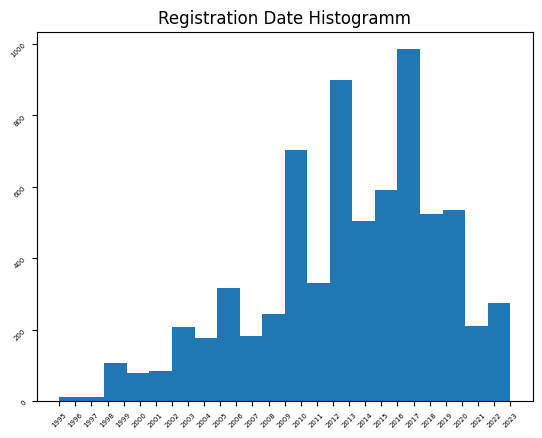

In [29]:
plt.hist(df_vwg["year"], bins=20)
plt.tick_params(labelrotation=45, labelsize=5)
plt.title("Registration Date Histogramm")
plt.plot()

[]

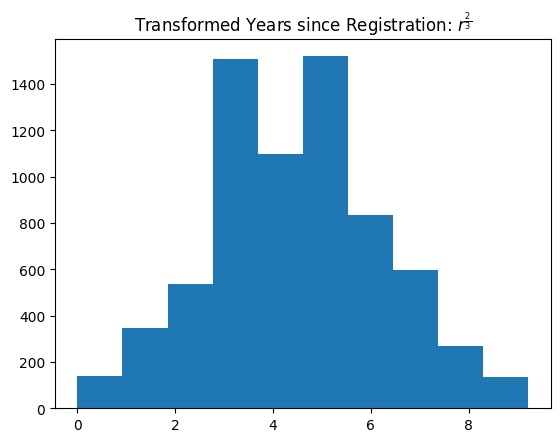

In [35]:
plt.hist((2023-df_vwg["year"].astype(int))**(2/3))
plt.title(r"Transformed Years since Registration: $r^{\frac{2}{3}}$")
plt.plot()

{'whiskers': [<matplotlib.lines.Line2D at 0x7f82290ac6d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f82290ad8d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f82290bcc50>],
 'medians': [<matplotlib.lines.Line2D at 0x7f82290b0a50>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f82290b1950>],
 'means': []}

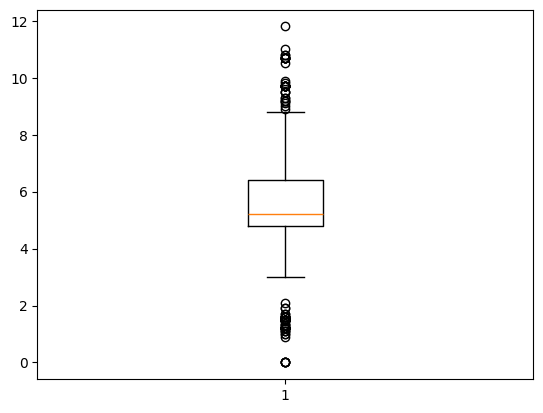

In [18]:
plt.boxplot(df_vwg[df_vwg["fuel_consumption_l_100km"] < 50]["fuel_consumption_l_100km"])

{'whiskers': [<matplotlib.lines.Line2D at 0x7f82290cc810>,
 'caps': [<matplotlib.lines.Line2D at 0x7f82290ce710>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f822b2d8a50>],
 'medians': [<matplotlib.lines.Line2D at 0x7f82290cd890>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f822b354590>],
 'means': []}

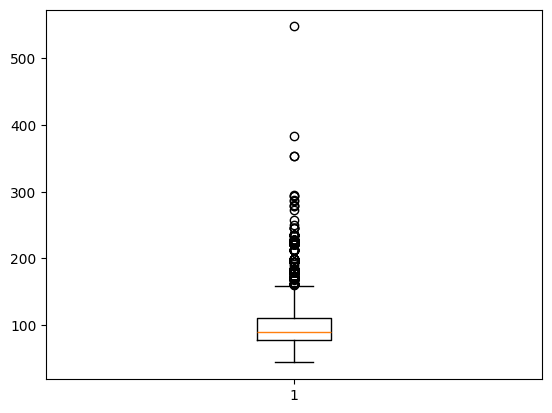

In [19]:
plt.boxplot(df_vwg["power_kw"])

Using matplotlib backend: module://matplotlib_inline.backend_inline


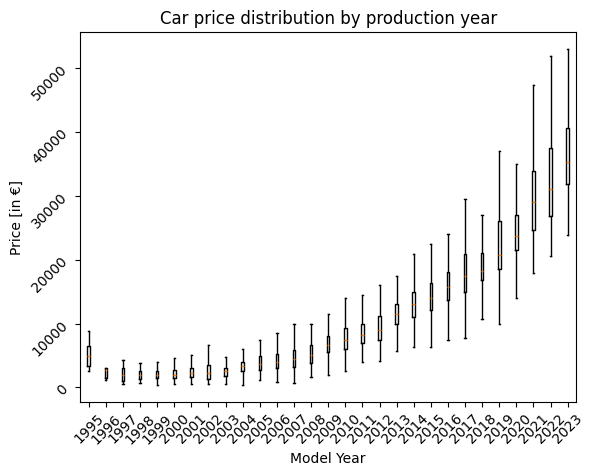

In [20]:
%matplotlib

for i, year in enumerate(df_vwg["year"].astype(int).unique()):
    cols = df_vwg[df_vwg["year"].astype(int) == year]
    plt.boxplot(cols["price_in_euro"], positions=[i], showfliers=False)

lbls=df_vwg["year"].astype(int).unique()
plt.xticks(ticks=range(len(lbls)), labels=lbls)
plt.tick_params(labelrotation=45, labelsize=10)
plt.xlabel("Model Year")
plt.ylabel("Price [in €]")
plt.title("Car price distribution by production year")
plt.show()

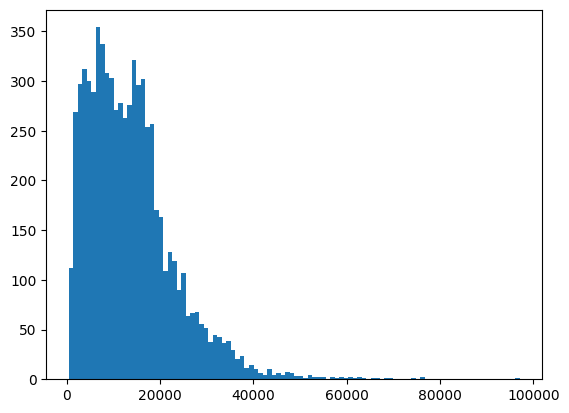

In [21]:
plt.hist(df_vwg["price_in_euro"], bins=100)
plt.show()

In [22]:
df_vwg[df_vwg["price_in_euro"] > 80_000]

,brand,model,color,registration_date,year,price_in_euro,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,offer_description
index,,,,,,,,,,,,,,
229776,volkswagen,Volkswagen Golf,grey,2015-11-01,2015,97050,81,110,Manual,Petrol,4.9,114 g/km,113464.0,1.2 TSI BlueMotion Technology Comfortline


In [ ]:
df["model"].value_counts()

model
Volkswagen Golf            6982
Opel Astra                 4051
Opel Corsa                 3903
SEAT Leon                  3748
Ford Focus                 3521
                           ... 
Volkswagen Corrado            1
Volkswagen Polo Variant       1
Volkswagen Polo Sedan         1
Volkswagen Käfer              1
Volkswagen Atlas              1
Name: count, Length: 1226, dtype: int64

In [24]:
df[df["model"] == "Volkswagen Golf"].head()

,brand,model,color,registration_date,year,price_in_euro,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,offer_description
index,,,,,,,,,,,,,,
213644,volkswagen,Volkswagen Golf,blue,1995-08-01,1995,4970,66,90,Manual,Petrol,8.0,192 g/km,159243.0,Cabrio 1.8 Colour Concept
213645,volkswagen,Volkswagen Golf,blue,1995-02-01,1995,2590,66,90,Automatic,Petrol,6.8,196 g/km,141600.0,1.8 Pink Floyd *AUTOMATIK / 2.HAND / TÜV NEU*
213647,volkswagen,Volkswagen Golf,blue,1995-11-01,1995,8900,128,174,Automatic,Petrol,10.5,252 g/km,162640.0,3 2.8 VR6 Colour Concept Leder Klima Sitzheizung
213650,volkswagen,Volkswagen Golf,blue,1995-11-01,1995,6399,44,60,Manual,Petrol,6.8,170 g/km,52523.0,"Movie. 1. Hand .52523km , Top-Zustand!"
213662,volkswagen,Volkswagen Golf,red,1995-06-01,1995,6600,66,90,Manual,Diesel,5.0,137 g/km,159450.0,"1,9 TDI ROLLING STONES COLLECTION 1. BESITZ"
